# 02 · Model 1 - TF-IDF + Logistic Regression baseline
**Owner:** Sonaksh Jain · **Family:** classical (linear) baseline

Bag-of-n-grams with TF-IDF weighting and L2-regularised logistic regression. It sees the **whole review** (no truncation) and gives a reference point for the deep models.

Protocol: features fitted on the training split only; n-gram range and regularisation strength `C` selected on validation F1; the test split is scored once with the selected configuration.

In [1]:
# ---- Setup: runs locally (from notebooks/) or on Google Colab ----
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    # Keep data and results on Drive so every notebook in the series sees them.
    from google.colab import drive
    drive.mount("/content/drive")
    ROOT = Path("/content/drive/MyDrive/dl-sentiment-project")
else:
    ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

RAW = ROOT / "data" / "raw"
PROC = ROOT / "data" / "processed"
RESULTS = ROOT / "results"
FIG = RESULTS / "figures"
for d in (RAW, PROC, RESULTS, FIG):
    d.mkdir(parents=True, exist_ok=True)
print("project root:", ROOT)

project root: C:\Users\akash\Documents\Study Material\07 Sem7\DL Project


In [2]:
# ---- Common evaluation protocol (identical in every model notebook) ----
import numpy as np
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score, precision_score,
                             recall_score, roc_auc_score)

def compute_metrics(y_true, prob):
    y_true, prob = np.asarray(y_true), np.asarray(prob)
    pred = (prob >= 0.5).astype(int)
    return {"accuracy": accuracy_score(y_true, pred), "precision": precision_score(y_true, pred),
            "recall": recall_score(y_true, pred), "f1": f1_score(y_true, pred),
            "macro_f1": f1_score(y_true, pred, average="macro"), "roc_auc": roc_auc_score(y_true, prob),
            "confusion_matrix": confusion_matrix(y_true, pred).tolist()}

def summarize_runs(runs):
    """Mean and std of test metrics over seeds."""
    keys = ["accuracy", "precision", "recall", "f1", "macro_f1", "roc_auc"]
    vals = {k: [r["test"][k] for r in runs] for k in keys}
    return ({k: float(np.mean(v)) for k, v in vals.items()},
            {k: float(np.std(v)) for k, v in vals.items()})

def save_results(key, result, probs_by_seed, primary_seed=42):
    """results/<key>/metrics.json + per-seed test probabilities (primary seed -> test_probs.npy)."""
    import json
    out = RESULTS / key
    out.mkdir(parents=True, exist_ok=True)
    result["test_mean"], result["test_std"] = summarize_runs(result["runs"])
    (out / "metrics.json").write_text(json.dumps(result, indent=2, default=float))
    for seed, p in probs_by_seed.items():
        np.save(out / f"test_probs_seed{seed}.npy", np.asarray(p, dtype=np.float32))
    np.save(out / "test_probs.npy", np.asarray(probs_by_seed[primary_seed], dtype=np.float32))
    m, s = result["test_mean"], result["test_std"]
    print(f"[{key}] test over {len(result['runs'])} run(s): acc {m['accuracy']:.4f} +/- {s['accuracy']:.4f} | "
          f"F1 {m['f1']:.4f} +/- {s['f1']:.4f} | AUC {m['roc_auc']:.4f}")

In [3]:
import time
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

SEED = 42
splits = {s: pd.read_csv(PROC / f"{s}.csv") for s in ("train", "val", "test")}
y = {s: df["label"].values for s, df in splits.items()}
TOKEN_PATTERN = r"[a-z0-9]+(?=n't)|n't|'(?:s|m|re|ve|ll|d)\b|[a-z0-9]+|[!?]"     # same tokenizer as the neural models

def vectorizer(ngram):
    return TfidfVectorizer(ngram_range=ngram, min_df=2, max_df=0.95, max_features=200_000,
                           sublinear_tf=True, token_pattern=TOKEN_PATTERN)

## Model selection (validation only)
Search over n-gram range {unigrams, uni+bigrams} × C ∈ {0.25 … 64}.

In [4]:
C_GRID = [0.25, 0.5, 1, 2, 4, 8, 16, 32, 64]
search = []
features = {}
for ngram in [(1, 1), (1, 2)]:
    vec = vectorizer(ngram)
    x_tr = vec.fit_transform(splits["train"]["text"])
    x_va = vec.transform(splits["val"]["text"])
    features[ngram] = (vec, x_tr, x_va)
    for c in C_GRID:
        clf = LogisticRegression(C=c, max_iter=3000, random_state=SEED).fit(x_tr, y["train"])
        m = compute_metrics(y["val"], clf.predict_proba(x_va)[:, 1])
        search.append({"ngram": f"{ngram[0]}-{ngram[1]}", "C": c, "val_acc": m["accuracy"], "val_f1": m["f1"]})
search_df = pd.DataFrame(search)
display(search_df.pivot(index="C", columns="ngram", values="val_f1").round(4))
best = search_df.sort_values("val_f1", ascending=False).iloc[0]
best_ngram, best_c = tuple(int(v) for v in best["ngram"].split("-")), float(best["C"])
print("selected: ngram", best_ngram, "C", best_c)

ngram,1-1,1-2
C,,
0.25,0.8698,0.8739
0.50,0.8788,0.8869
1.00,0.8831,0.8912
2.00,0.8880,0.8937
4.00,0.8868,0.8957
8.00,0.8872,0.9015
16.00,0.8846,0.9033
32.00,0.8851,0.9018
64.00,0.8781,0.9020


selected: ngram (1, 2) C 16.0


## Final model and test evaluation
Training time = vectorisation + one logistic-regression fit (search time excluded, as for the neural models).

In [5]:
t0 = time.time()
vec = vectorizer(best_ngram)
x_tr = vec.fit_transform(splits["train"]["text"])
clf = LogisticRegression(C=best_c, max_iter=3000, random_state=SEED).fit(x_tr, y["train"])
train_time = time.time() - t0

x_va = vec.transform(splits["val"]["text"])
t1 = time.time()
p_test = clf.predict_proba(vec.transform(splits["test"]["text"]))[:, 1]
infer_time = time.time() - t1

# ablation: the best unigram-only model, scored on test for the discussion
uni = search_df[search_df.ngram == "1-1"].sort_values("val_f1", ascending=False).iloc[0]
v1, xt1, _ = features[(1, 1)]
clf1 = LogisticRegression(C=float(uni["C"]), max_iter=3000, random_state=SEED).fit(xt1, y["train"])
uni_test = compute_metrics(y["test"], clf1.predict_proba(v1.transform(splits["test"]["text"]))[:, 1])
ablations = [
    {"variant": f"uni+bigrams, C={best_c:g} (selected)", "val_f1": float(best["val_f1"]),
     "test_acc": float(compute_metrics(y["test"], p_test)["accuracy"]), "test_f1": float(compute_metrics(y["test"], p_test)["f1"])},
    {"variant": f"unigrams only, C={float(uni['C']):g}", "val_f1": float(uni["val_f1"]),
     "test_acc": uni_test["accuracy"], "test_f1": uni_test["f1"]},
]
display(pd.DataFrame(ablations))

names = vec.get_feature_names_out()
order = clf.coef_[0].argsort()
run = {"seed": SEED, "config": {"ngram_range": list(best_ngram), "C": best_c},
       "val": compute_metrics(y["val"], clf.predict_proba(x_va)[:, 1]), "test": compute_metrics(y["test"], p_test),
       "train_time_s": train_time, "infer_time_s": infer_time, "history": [], "best_epoch": None}
save_results("tfidf_logreg", {
    "model": "TF-IDF + Logistic Regression", "owner": "Sonaksh Jain", "family": "Classical baseline",
    "final_variant": f"uni+bigrams, C={best_c:g}" if best_ngram == (1, 2) else f"unigrams, C={best_c:g}",
    "config": {"ngram_range": list(best_ngram), "C": best_c, "min_df": 2, "max_df": 0.95,
               "max_features": 200_000, "sublinear_tf": True},
    "search": search, "ablations": ablations, "n_features": len(names),
    "total_params": int(clf.coef_.size + 1), "trainable_params": int(clf.coef_.size + 1),
    "top_positive_ngrams": names[order[-25:][::-1]].tolist(), "top_negative_ngrams": names[order[:25]].tolist(),
    "runs": [run],   # deterministic solver: a single run (std = 0)
}, {SEED: p_test})

,variant,val_f1,test_acc,test_f1
0,"uni+bigrams, C=16 (selected)",0.903277,0.9072,0.907155
1,"unigrams only, C=2",0.888003,0.8906,0.890534


[tfidf_logreg] test over 1 run(s): acc 0.9072 +/- 0.0000 | F1 0.9072 +/- 0.0000 | AUC 0.9678


## Interpretation - the most polar n-grams
The learned weights are directly readable: the strongest features are explicit polarity words and rating mentions (*7 10* = "7/10").

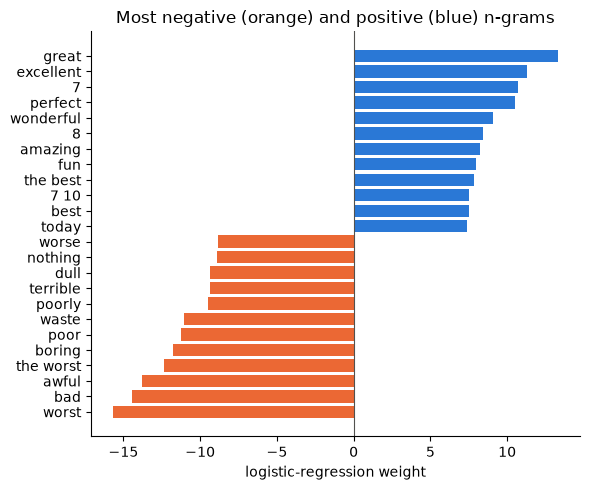

In [6]:
import matplotlib.pyplot as plt
w = clf.coef_[0]
top = np.r_[order[:12], order[-12:]]
fig, ax = plt.subplots(figsize=(6, 5))
ax.barh(range(len(top)), w[top], color=["#eb6834" if v < 0 else "#2a78d6" for v in w[top]])
ax.set_yticks(range(len(top)), names[top]); ax.axvline(0, color="#52514e", lw=.8)
ax.set(xlabel="logistic-regression weight", title="Most negative (orange) and positive (blue) n-grams")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); fig.savefig(FIG / "tfidf_top_ngrams.png", dpi=200); plt.show()

## Baseline validation note

The linear baseline is retained as a reference point for the neural models. Keep the vectorizer fit on the training split only and report validation results before selecting the regularisation strength.
